# LSTM za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

1. Univarijatni signal (samo iznosi)

X shape: (337, 28, 1)
y shape: (337, 1)
Train samples: 221
Validation samples: 55
Test samples: 61
Using device: cpu
Epoch 010 | Train loss: 1.0158 | Val loss: 1.0236
Epoch 020 | Train loss: 1.0116 | Val loss: 1.0251
Epoch 030 | Train loss: 1.0038 | Val loss: 1.0277
Epoch 040 | Train loss: 1.0001 | Val loss: 1.0250
Epoch 050 | Train loss: 0.9790 | Val loss: 1.0085
Epoch 060 | Train loss: 0.8922 | Val loss: 1.0264
Epoch 070 | Train loss: 0.9350 | Val loss: 0.9980
Epoch 080 | Train loss: 0.8142 | Val loss: 1.0221
Epoch 090 | Train loss: 0.7936 | Val loss: 1.0878
Epoch 100 | Train loss: 0.6853 | Val loss: 1.1526
Epoch 110 | Train loss: 0.6025 | Val loss: 1.1917
Epoch 120 | Train loss: 0.5255 | Val loss: 1.5005
Epoch 130 | Train loss: 0.4842 | Val loss: 1.4077
Epoch 140 | Train loss: 0.4438 | Val loss: 1.7048
Epoch 150 | Train loss: 0.4135 | Val loss: 1.7315
Epoch 160 | Train loss: 0.3780 | Val loss: 1.8806
Epoch 170 | Train loss: 0.3375 | Val loss: 1.9008
Epoch 180 | Train loss: 0.3218 | 

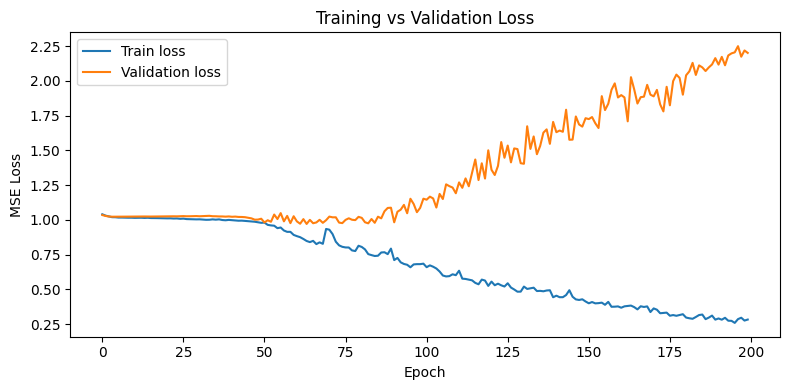

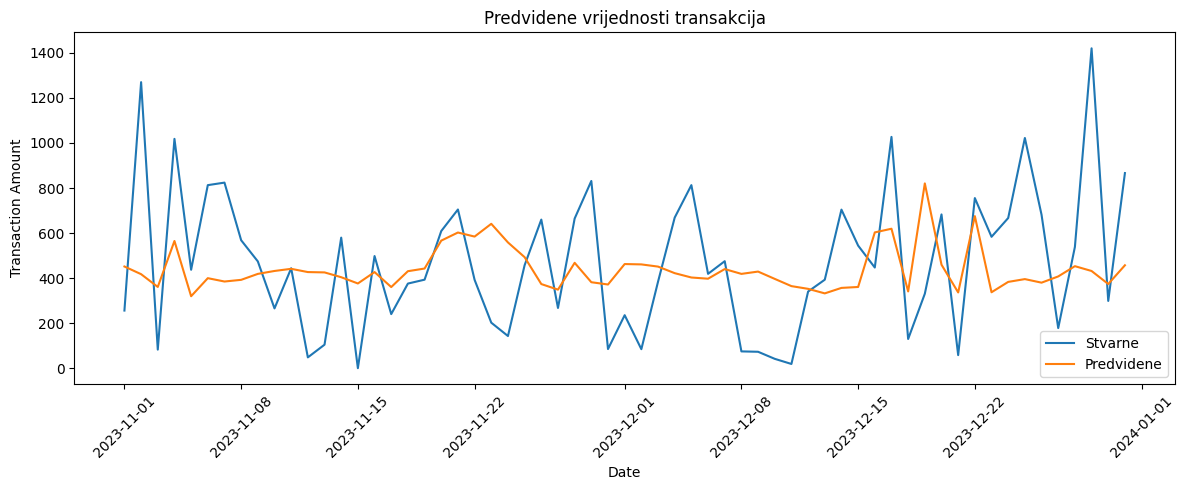

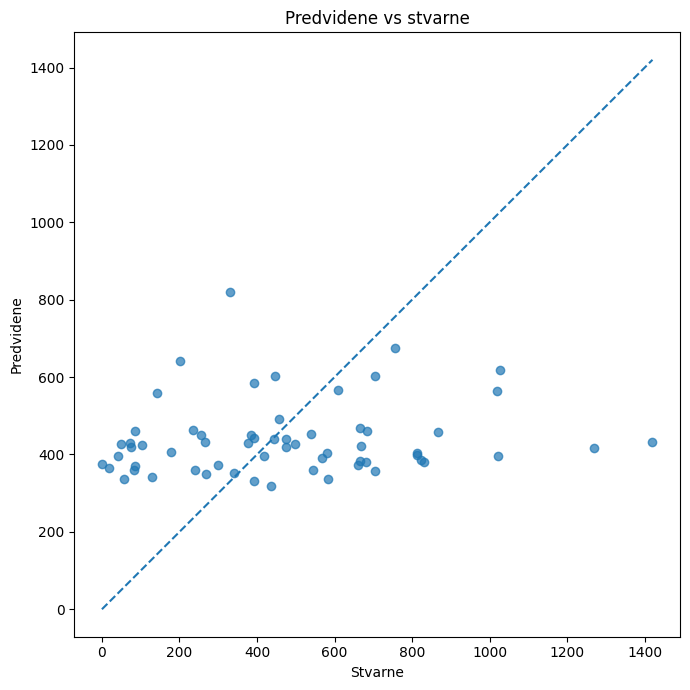

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ciscenje
df = pd.read_csv("dataset.csv")
df = df[df["User_ID"] != "USER_0007"].copy()

df["Location"] = df["Location"].replace("Lndn","London")

df = df.loc[df["Transaction_Amount"] > 0,:].copy()

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date","Total_Transaction"]
daily["Date"] = pd.to_datetime(daily["Date"])

daily = (
    daily
    .set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)

daily = daily.sort_values("Date").reset_index(drop=True)

values_raw = daily["Total_Transaction"].values.reshape(-1, 1)



#split i z-scale
split_date = pd.Timestamp("2023-11-01")
train_mask = ( daily["Date"] < split_date)

scaler = StandardScaler()
scaler.fit(values_raw[train_mask])
values_scaled = scaler.transform(values_raw)


# =====================================================
# WINDOW CREATION
# =====================================================

window_size = 28

X = []
y = []
dates = []

for i in range( len(values_scaled) - window_size):

    window = values_scaled[i:i + window_size]
    target = values_scaled[i + window_size]

    X.append(window)
    y.append(target)

    dates.append(daily["Date"].iloc[i + window_size])

X = np.array(X,dtype=np.float32)
y = np.array(y,dtype=np.float32)

dates = np.array(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)


# =====================================================
# TRAIN / VALIDATION / TEST SPLIT
# treba nam i validacijski skup (20% od trening skupa) za provjeru tijekom treniranja
# =====================================================
dates = np.array(dates)

train_val_idx = np.where(dates < split_date)[0]
test_idx = np.where(dates >= split_date)[0]

val_size = int(0.2 * len(train_val_idx))

train_idx = train_val_idx[:-val_size]
val_idx = train_val_idx[-val_size:]

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))



# priprema TORCH DATASETS
batch_size = 16

train_ds = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train)
)

val_ds = TensorDataset(
    torch.tensor(X_val),
    torch.tensor(y_val)
)

test_ds = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(y_test)
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False
)



class LSTMRegressor(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        out = self.fc(last_hidden)
        return out

    def get_lstm_outputs(self, x):  #helper za vizualizaciju kasnije
        out, (h, c) = self.lstm(x)
        return out, h, c




device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device:", device)



model = LSTMRegressor().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)



# treniranje + validacija; sprema najbolji model

epochs = 200

train_losses = []
val_losses = []

best_val_loss = np.inf
best_model_path = "best_lstm_model.pt"

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        preds = model(xb)

        loss = criterion(preds, yb)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    train_losses.append(train_loss)

    # validacija
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)

            loss = criterion(preds, yb)

            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)

    val_losses.append(val_loss)

    # spremi najbolji
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f}"
        )

print("Best validation loss:", best_val_loss)


# ucitavanje najboljeg modela i predikcija (paziti na skaliranje)
model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model.eval()

preds_scaled = []

with torch.no_grad():

    for xb, _ in test_loader:

        xb = xb.to(device)

        preds = model(xb)

        preds_scaled.extend(
            preds.cpu().numpy()
        )

preds_scaled = np.array( preds_scaled)
y_pred = scaler.inverse_transform( preds_scaled)
y_true = scaler.inverse_transform(y_test)


mae = mean_absolute_error(y_true,y_pred)
mse = mean_squared_error(y_true,y_pred)

rmse = np.sqrt(mse)

print("\nRESULTS")
print("MAE :", mae)
print("RMSE:", rmse)


# PLOTOVI

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(dates[test_idx], y_true, label="Stvarne")
plt.plot(dates[test_idx],y_pred,label="Predvidene")
plt.title("Predvidene vrijednosti transakcija")
plt.xlabel("Date")
plt.ylabel("Transaction Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



plt.figure(figsize=(7, 7))
plt.scatter(y_true,y_pred,alpha=0.7)
min_val = min(y_true.min(),y_pred.min())
max_val = max(y_true.max(),y_pred.max())
plt.plot([min_val, max_val],[min_val, max_val],linestyle="--")
plt.xlabel("Stvarne")
plt.ylabel("Predvidene")
plt.title("Predvidene vs stvarne")
plt.tight_layout()
plt.show()

*Model je opet naučio mean*

## 2. XAI

#### Aktivacija skrivenog sloja za neke uzorke

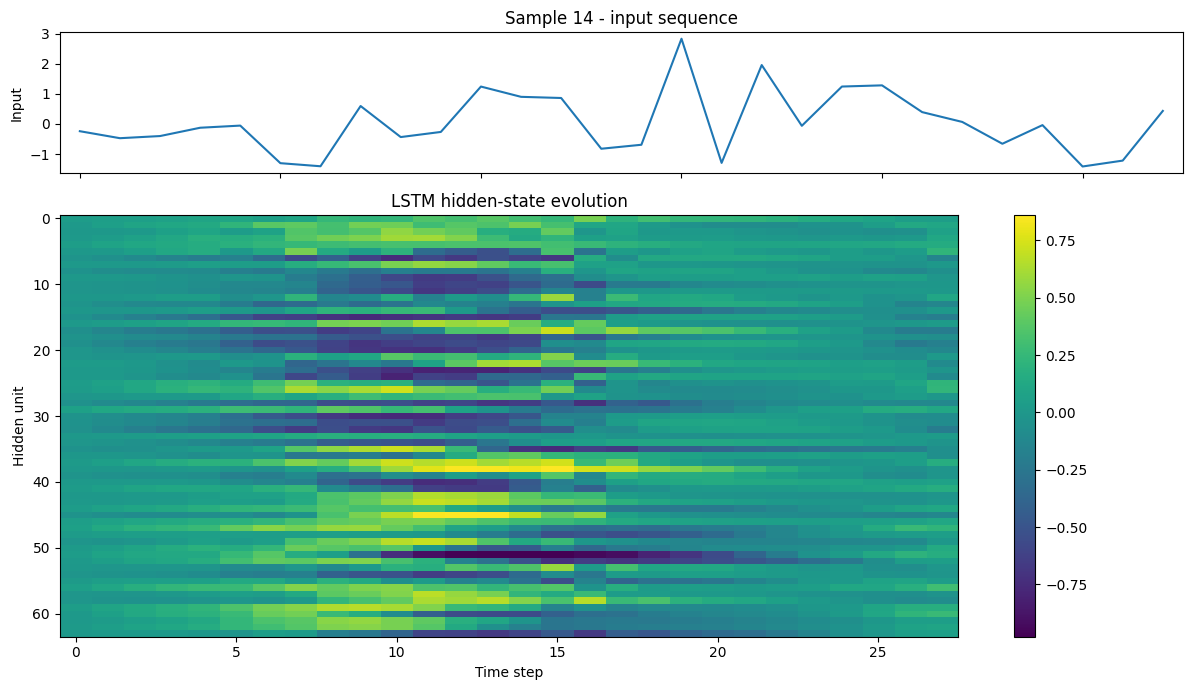

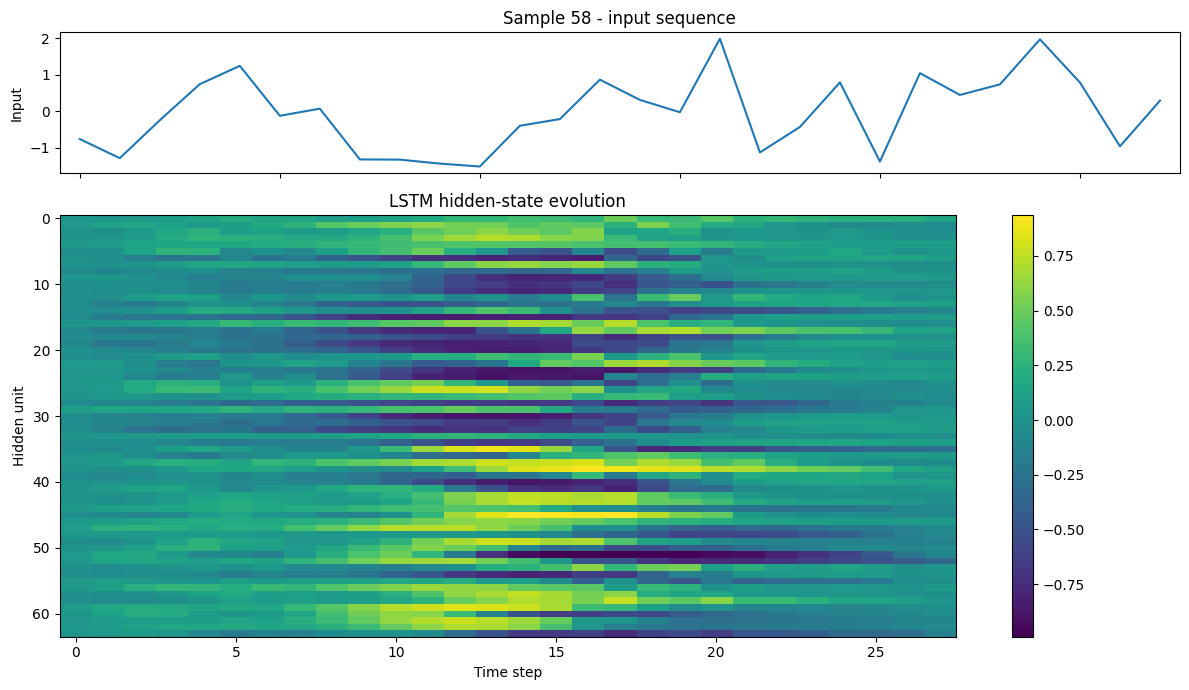

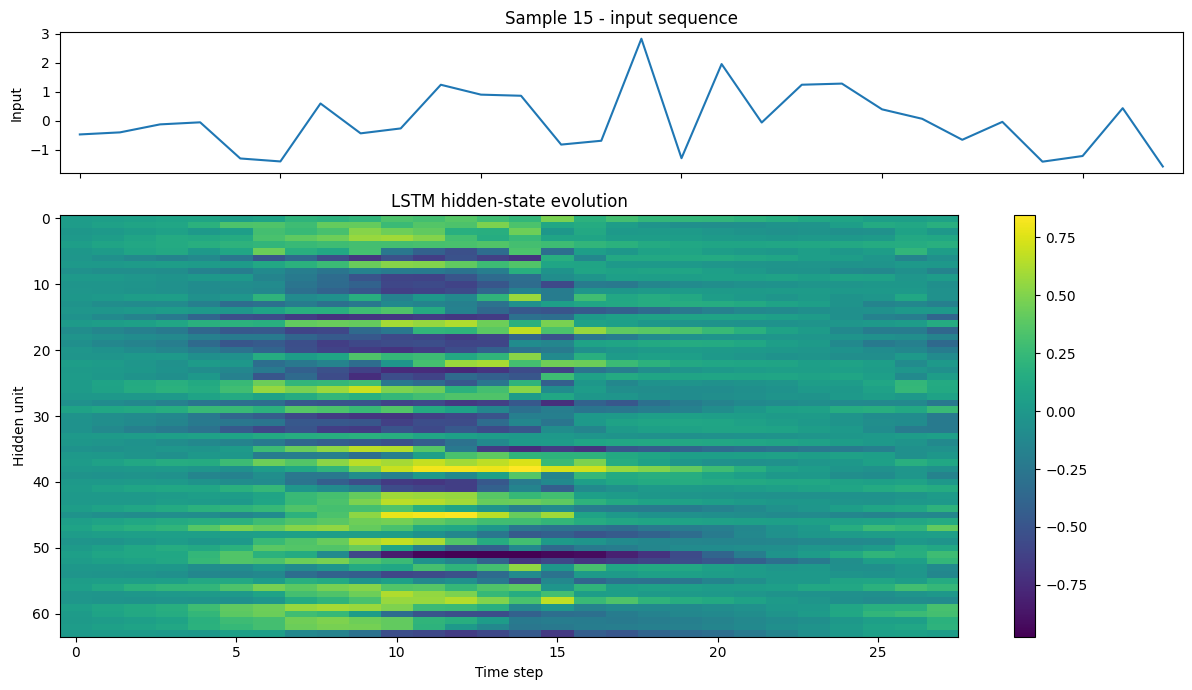

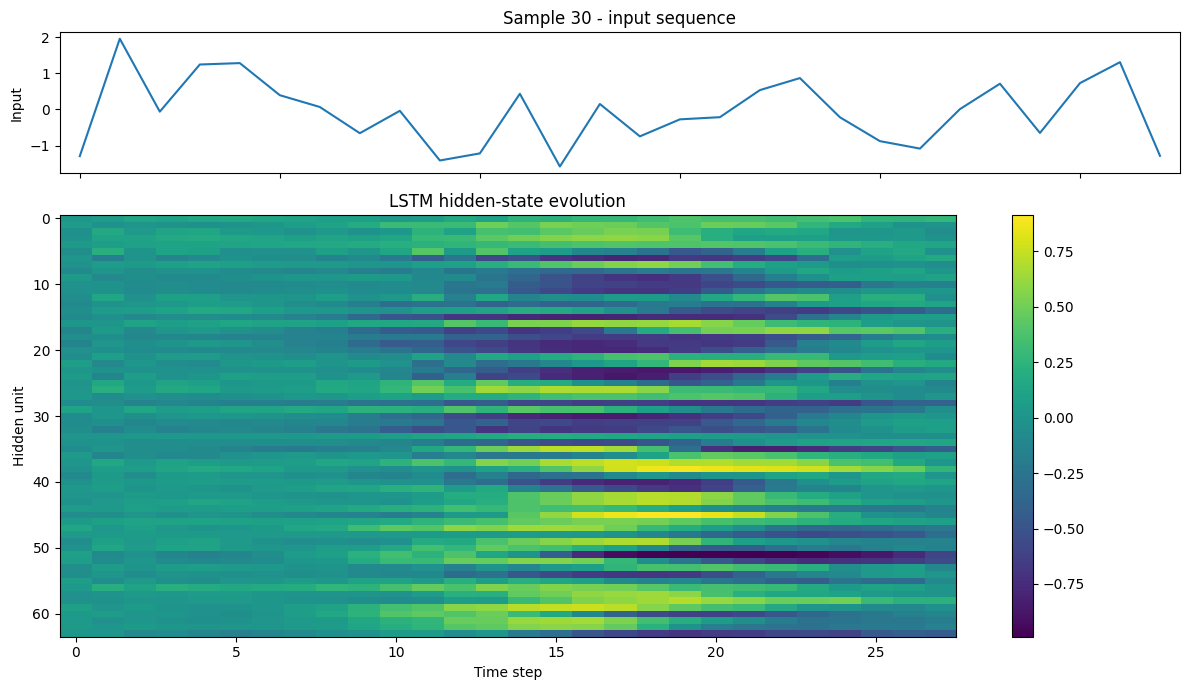

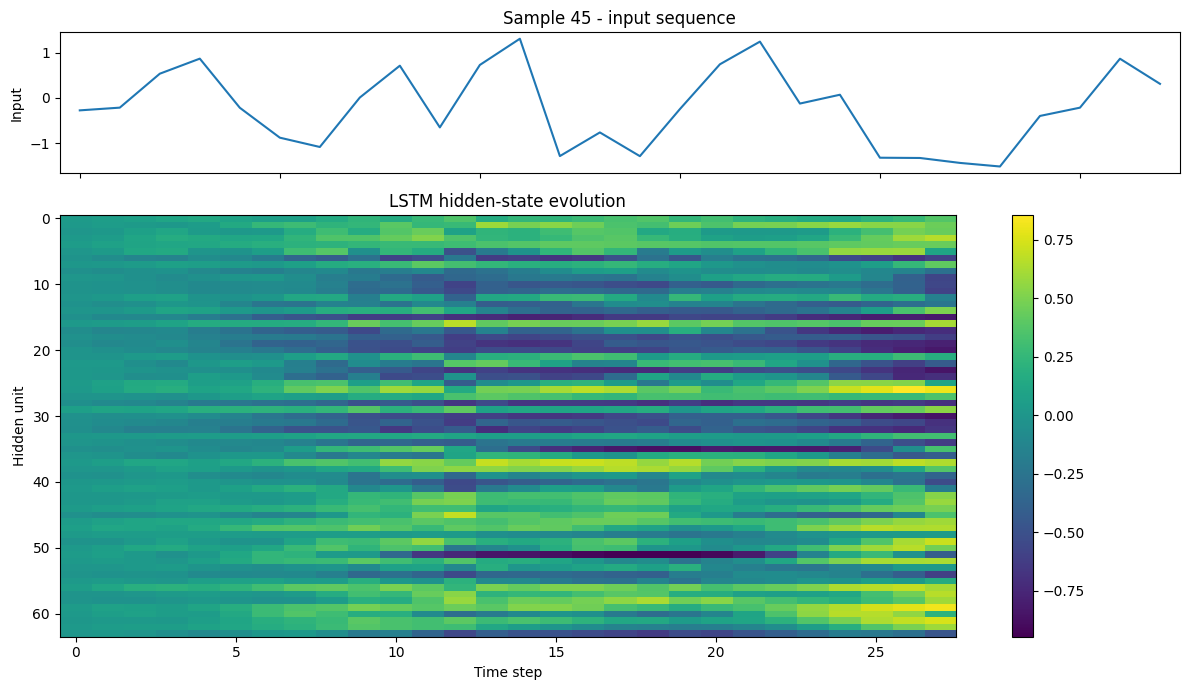

In [2]:
y_test_flat = y_test.ravel()

#odabiremo uzorke: ekstremi + na pocetku/sredini/pred kraj
sample_ids = [
    np.argmin(y_test_flat),              # lowest actual target
    np.argmax(y_test_flat),              # highest actual target
    len(y_test_flat) // 4,
    len(y_test_flat) // 2,
    3 * len(y_test_flat) // 4
]


for sample_id in sample_ids:

    sample = torch.tensor(
        X_test[sample_id:sample_id + 1]
    ).to(device)

    model.eval()

    with torch.no_grad():
        hidden_seq, h, c = model.get_lstm_outputs(sample)

    hidden_seq = hidden_seq.cpu().numpy()[0]
    sample_series = X_test[sample_id].squeeze()

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    axes[0].plot(sample_series)
    axes[0].set_ylabel("Input")
    axes[0].set_title(f"Sample {sample_id} - input sequence")

    im = axes[1].imshow(
        hidden_seq.T,
        aspect="auto"
    )

    axes[1].set_ylabel("Hidden unit")
    axes[1].set_xlabel("Time step")
    axes[1].set_title("LSTM hidden-state evolution")

    fig.colorbar(im, ax=axes[1])

    plt.tight_layout()
    plt.show()

*Uzorci 14 i 15 imaju gotovo identične aktivacije skrivenih stanja -> čini se da LSTM **prepoznaje vrlo slične vremenske obrasce** unatoč manjim razlikama u ulaznim podacima. Kod uzorka 58 aktivacije traju nešto dulje, što može značiti da **model dulje “pamti” izraženije promjene u sekvenci**.*

*Kod uzorka 30 glavne aktivacije pojavljuju se kasnije u vremenskom prozoru, što sugerira da model reagira na promjene i prijelaze u signalu, a ne samo na određene pozicije u sekvenci.*

*Uzorak 45 pokazuje raspodijeljenije aktivacije bez jednog dominantnog područja, što može upućivati na složeniji ili manje stabilan obrazac signala.*

*Iste skrivene jedinice često dominiraju kroz različite uzorke -> moguće je da su se pojedine jedinice specijalizirale za prepoznavanje određenih vremenskih obrazaca. Također, dio skrivenih jedinica ostaje slabo aktivan kroz većinu uzoraka (model ne koristi sve ćelije podjednako).*



#### Koliko se aktivira svaka ćelija (u prosjeku)

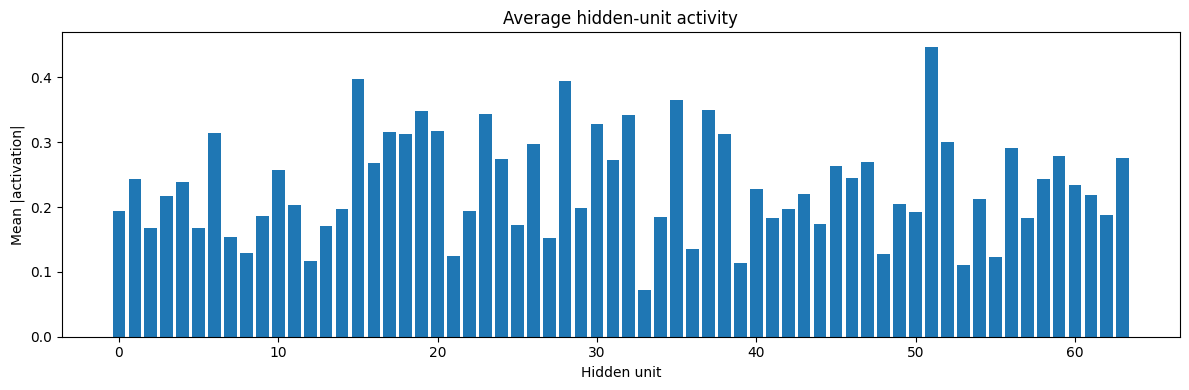

In [3]:
all_hidden = []

model.eval()

with torch.no_grad():

    for i in range(len(X_test)):

        sample = torch.tensor(
            X_test[i:i+1]
        ).to(device)

        hidden_seq, h, c = model.get_lstm_outputs(sample)

        hidden_seq = hidden_seq.cpu().numpy()[0]

        all_hidden.append(hidden_seq)

all_hidden = np.array(all_hidden)

# shape:
# (samples, timesteps, hidden_units)

mean_activation = np.mean(
    np.abs(all_hidden),
    axis=(0, 1)
)

plt.figure(figsize=(12,4))

plt.bar(
    np.arange(len(mean_activation)),
    mean_activation
)

plt.xlabel("Hidden unit")
plt.ylabel("Mean |activation|")

plt.title("Average hidden-unit activity")

plt.tight_layout()
plt.show()

#### Occlusion - importance: koji dio prozora je najvažniji (lokalno i globalno)

- postupno se uklanja pojedini vremenski korak iz ulazne sekvence te se promatra koliko se promijeni predikcija modela. Veća promjena predikcije ukazuje na veću važnost tog dijela sekvence za donošenje odluke modela.

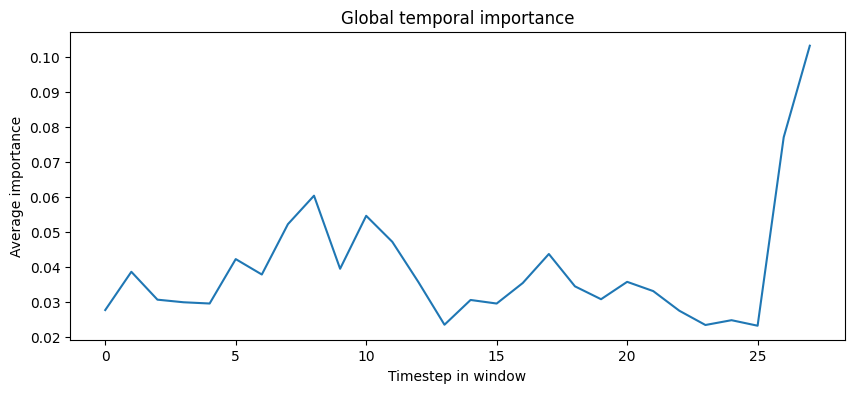

In [7]:
global_importance = np.zeros(window_size)

model.eval()

for sample_id in range(len(X_test)):

    sample = torch.tensor(
        X_test[sample_id:sample_id+1]
    ).to(device)

    with torch.no_grad():

        baseline = model(sample).item()

    local_importance = []   #lokalno

    for t in range(window_size):

        modified = sample.clone()

        modified[0, t, 0] = 0

        with torch.no_grad():

            perturbed = model(modified).item()

        importance = abs(
            perturbed - baseline
        )

        local_importance.append(
            importance
        )

    global_importance += np.array(  #agregiranje
        local_importance
    )

global_importance /= len(X_test)

plt.figure(figsize=(10,4))

plt.plot(global_importance)

plt.xlabel("Timestep in window")
plt.ylabel("Average importance")

plt.title("Global temporal importance")

plt.show()

*S obzirom da u skupu ne postoji jasno izražena periodičnost niti sezonalnost, ima smisla da na predviđanje najviše utječu najbliži dani u prošlosti.*